# Week 6 Jupyter Notebook — Decision Trees and Random Forests  
## Integrated Capstone Project: Wisconsin and Coimbra Breast Cancer Datasets

**Week topic:** Decision trees and random forests

### Notebook purpose

For Week 6, I am applying decision trees and random forests to both of my capstone datasets:

1. **Breast Cancer Wisconsin Diagnostic dataset**  
   This dataset uses tumor image-based measurements such as radius, texture, perimeter, area, smoothness, and concavity.

2. **Breast Cancer Coimbra dataset**  
   This dataset uses clinical and blood-based biomarkers such as age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, and MCP-1.

I am not merging the two datasets because they do not contain the same patients or the same variables. Instead, I am using them side-by-side to compare how tree-based models perform on two different types of breast cancer data.

For this week, I focus on:

- Decision trees
- Random forests
- Tree depth and pruning
- Feature importance
- Overfitting prevention
- Model comparison across both datasets

Since both datasets have binary outcomes, this is a classification task.


## 1. Import libraries

I am importing the libraries needed for loading both datasets, training decision tree and random forest models, tuning hyperparameters, and evaluating classification performance.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


# Part A: Breast Cancer Wisconsin Diagnostic Dataset

## 2. Load and prepare the Wisconsin dataset

The sklearn version of the Wisconsin dataset originally uses:

- `0 = malignant`
- `1 = benign`

For this notebook, I switch the target so that:

- `diagnosis_malignant = 1` means malignant
- `diagnosis_malignant = 0` means benign

This makes the interpretation easier because malignant diagnosis is the positive class.


In [2]:
# Load Wisconsin dataset
cancer = load_breast_cancer()

wisconsin_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
wisconsin_df.columns = wisconsin_df.columns.str.replace(" ", "_")

wisconsin_df["diagnosis_malignant"] = (cancer.target == 0).astype(int)
wisconsin_df["diagnosis_label"] = np.where(wisconsin_df["diagnosis_malignant"] == 1, "Malignant", "Benign")

print("Wisconsin dataset shape:", wisconsin_df.shape)
print("\nDiagnosis counts:")
print(wisconsin_df["diagnosis_label"].value_counts())

print("\nDiagnosis percentages:")
print(wisconsin_df["diagnosis_label"].value_counts(normalize=True).round(3))

wisconsin_df.head()


Wisconsin dataset shape: (569, 32)

Diagnosis counts:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64

Diagnosis percentages:
diagnosis_label
Benign       0.627
Malignant    0.373
Name: proportion, dtype: float64


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_malignant,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


## 3. Wisconsin features and target

The Wisconsin dataset has 30 tumor measurement features. These features describe the shape, size, and texture of tumor cell nuclei from digitized images.


In [3]:
wisconsin_target = "diagnosis_malignant"
wisconsin_label = "diagnosis_label"

wisconsin_features = [
    col for col in wisconsin_df.columns
    if col not in [wisconsin_target, wisconsin_label]
]

X_w = wisconsin_df[wisconsin_features]
y_w = wisconsin_df[wisconsin_target]

print("Number of rows:", X_w.shape[0])
print("Number of features:", X_w.shape[1])


Number of rows: 569
Number of features: 30


## 4. Quick Wisconsin EDA before tree models

Tree-based models can capture nonlinear relationships and feature interactions. Before modeling, I still want to check which features are most related to malignancy.


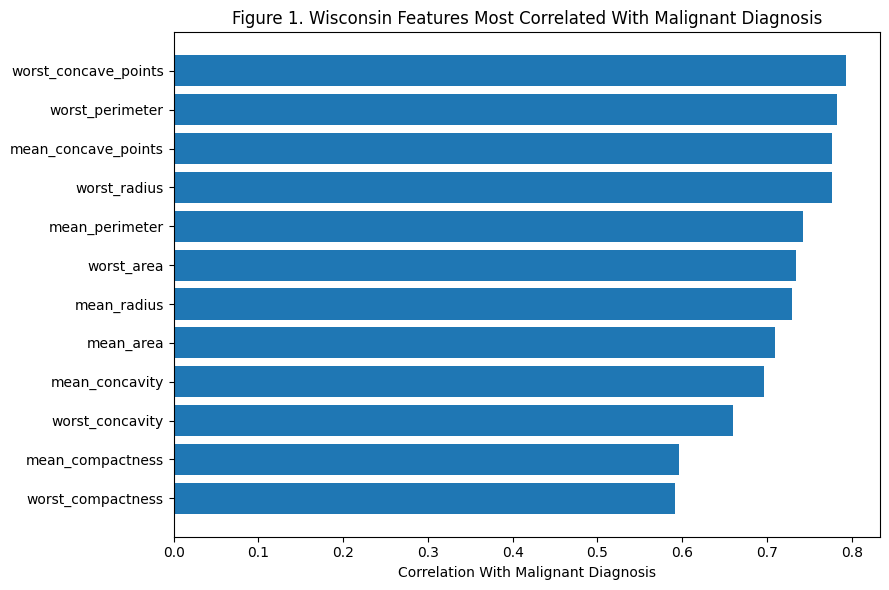

,feature,correlation_with_malignant
0,worst_compactness,0.590998
1,mean_compactness,0.596534
2,worst_concavity,0.659610
3,mean_concavity,0.696360
4,mean_area,0.708984
5,mean_radius,0.730029
6,worst_area,0.733825
7,mean_perimeter,0.742636
8,worst_radius,0.776454
9,mean_concave_points,0.776614


In [4]:
# Figure 1: Wisconsin features most correlated with malignant diagnosis
corr_with_target_w = wisconsin_df[wisconsin_features + [wisconsin_target]].corr()[wisconsin_target].drop(wisconsin_target)
top_corr_w = corr_with_target_w.abs().sort_values(ascending=False).head(12)
top_corr_w_signed = corr_with_target_w.loc[top_corr_w.index].sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_corr_w_signed.index, top_corr_w_signed.values)
plt.xlabel("Correlation With Malignant Diagnosis")
plt.title("Figure 1. Wisconsin Features Most Correlated With Malignant Diagnosis")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": top_corr_w_signed.index,
    "correlation_with_malignant": top_corr_w_signed.values
})


### Wisconsin EDA note

From earlier weeks, I expected size and shape-related variables to be important. Decision trees and random forests are useful here because they can capture interactions between these features without me manually creating interaction terms.


## 5. Wisconsin train-test split

I use a stratified train-test split so the benign and malignant proportions stay similar in both sets.


In [5]:
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_w,
    y_w,
    test_size=0.20,
    random_state=42,
    stratify=y_w
)

print("Training shape:", X_train_w.shape)
print("Testing shape:", X_test_w.shape)

print("\nTraining target distribution:")
print(y_train_w.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test_w.value_counts(normalize=True).round(3))


Training shape: (455, 30)
Testing shape: (114, 30)

Training target distribution:
diagnosis_malignant
0    0.626
1    0.374
Name: proportion, dtype: float64

Testing target distribution:
diagnosis_malignant
0    0.632
1    0.368
Name: proportion, dtype: float64


## 6. Evaluation helper function

For Week 6, I use classification metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

For this healthcare-related project, recall for malignant cases is especially important because missing a malignant tumor would be a serious concern.


In [6]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test, positive_label_name="Positive"):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        train_score = model.predict_proba(X_train)[:, 1]
        test_score = model.predict_proba(X_test)[:, 1]
    else:
        train_score = model.decision_function(X_train)
        test_score = model.decision_function(X_test)

    results = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision_positive": precision_score(y_test, test_pred, pos_label=1, zero_division=0),
        "test_recall_positive": recall_score(y_test, test_pred, pos_label=1),
        "test_f1_positive": f1_score(y_test, test_pred, pos_label=1),
        "test_roc_auc": roc_auc_score(y_test, test_score)
    }

    return results, train_pred, test_pred, train_score, test_score


## 7. Wisconsin baseline decision tree

I start with a basic decision tree. This model is easy to explain because it creates a sequence of if/then rules.

However, a decision tree can overfit if it grows too deep. So I first run a baseline tree, then tune it.


In [7]:
wisconsin_tree_baseline = DecisionTreeClassifier(
    random_state=42
)

w_tree_base_results, w_tree_base_train_pred, w_tree_base_test_pred, w_tree_base_train_score, w_tree_base_test_score = evaluate_classifier(
    "Wisconsin Baseline Decision Tree",
    wisconsin_tree_baseline,
    X_train_w,
    X_test_w,
    y_train_w,
    y_test_w
)

pd.DataFrame([w_tree_base_results])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Wisconsin Baseline Decision Tree,1.0,0.929825,0.904762,0.904762,0.904762,0.924603


### Baseline tree note

If the training accuracy is much higher than the testing accuracy, that suggests the tree may be overfitting. This is common with unrestricted decision trees.


## 8. Wisconsin tuned decision tree

To reduce overfitting, I tune decision tree hyperparameters:

- `max_depth`: limits how deep the tree can grow
- `min_samples_leaf`: requires each final leaf to have a minimum number of samples
- `min_samples_split`: controls how many samples are needed before a split can happen
- `criterion`: the split quality measure

These settings help prevent the tree from memorizing the training data.


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tree_param_grid = {
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

wisconsin_tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=tree_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1
)

wisconsin_tree_grid.fit(X_train_w, y_train_w)

print("Best Wisconsin decision tree parameters:")
print(wisconsin_tree_grid.best_params_)
print("\nBest cross-validated recall:", wisconsin_tree_grid.best_score_)

w_tree_tuned_results, w_tree_tuned_train_pred, w_tree_tuned_test_pred, w_tree_tuned_train_score, w_tree_tuned_test_score = evaluate_classifier(
    "Wisconsin Tuned Decision Tree",
    wisconsin_tree_grid.best_estimator_,
    X_train_w,
    X_test_w,
    y_train_w,
    y_test_w
)

pd.DataFrame([w_tree_base_results, w_tree_tuned_results])


Best Wisconsin decision tree parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}

Best cross-validated recall: 0.9


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Wisconsin Baseline Decision Tree,1.000000,0.929825,0.904762,0.904762,0.904762,0.924603
1,Wisconsin Tuned Decision Tree,0.991209,0.938596,0.926829,0.904762,0.915663,0.942460


## 9. Wisconsin decision tree visualization

This plot shows a simplified view of the tuned decision tree. I limit the depth in the plot so that it stays readable.


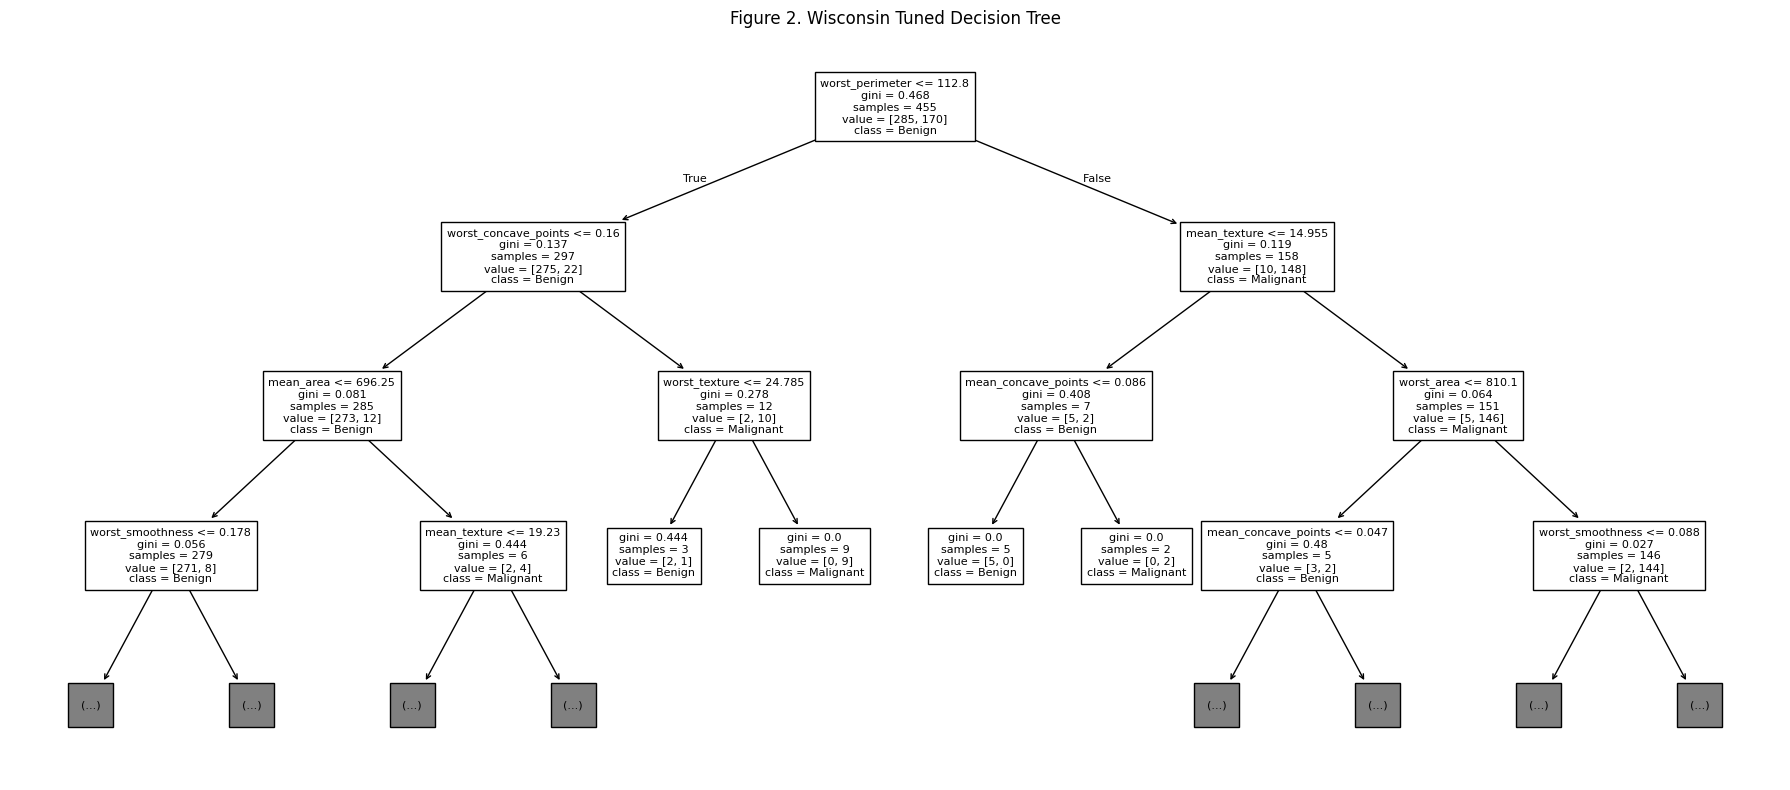

In [9]:
# Figure 2: Wisconsin tuned decision tree visualization
plt.figure(figsize=(18, 8))
plot_tree(
    wisconsin_tree_grid.best_estimator_,
    feature_names=wisconsin_features,
    class_names=["Benign", "Malignant"],
    max_depth=3,
    fontsize=8
)
plt.title("Figure 2. Wisconsin Tuned Decision Tree")
plt.tight_layout()
plt.show()


## 10. Wisconsin random forest

A random forest builds many decision trees and averages their results. This usually reduces overfitting compared with a single tree.

Random forests are useful for this dataset because tumor features can interact in complex ways.


In [10]:
wisconsin_rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

w_rf_base_results, w_rf_base_train_pred, w_rf_base_test_pred, w_rf_base_train_score, w_rf_base_test_score = evaluate_classifier(
    "Wisconsin Baseline Random Forest",
    wisconsin_rf_baseline,
    X_train_w,
    X_test_w,
    y_train_w,
    y_test_w
)

pd.DataFrame([w_tree_tuned_results, w_rf_base_results])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Wisconsin Tuned Decision Tree,0.991209,0.938596,0.926829,0.904762,0.915663,0.942460
1,Wisconsin Baseline Random Forest,1.000000,0.964912,1.000000,0.904762,0.950000,0.996032


## 11. Wisconsin tuned random forest

For the random forest, I tune:

- `n_estimators`: number of trees
- `max_depth`: maximum depth of each tree
- `min_samples_leaf`: minimum samples in each leaf
- `max_features`: number of features considered at each split

This helps balance performance and overfitting.


In [11]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

wisconsin_rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=rf_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1
)

wisconsin_rf_grid.fit(X_train_w, y_train_w)

print("Best Wisconsin random forest parameters:")
print(wisconsin_rf_grid.best_params_)
print("\nBest cross-validated recall:", wisconsin_rf_grid.best_score_)

w_rf_tuned_results, w_rf_tuned_train_pred, w_rf_tuned_test_pred, w_rf_tuned_train_score, w_rf_tuned_test_score = evaluate_classifier(
    "Wisconsin Tuned Random Forest",
    wisconsin_rf_grid.best_estimator_,
    X_train_w,
    X_test_w,
    y_train_w,
    y_test_w
)

pd.DataFrame([w_tree_tuned_results, w_rf_base_results, w_rf_tuned_results])


Best Wisconsin random forest parameters:
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}

Best cross-validated recall: 0.9529411764705882


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Wisconsin Tuned Decision Tree,0.991209,0.938596,0.926829,0.904762,0.915663,0.942460
1,Wisconsin Baseline Random Forest,1.000000,0.964912,1.000000,0.904762,0.950000,0.996032
2,Wisconsin Tuned Random Forest,0.993407,0.973684,1.000000,0.928571,0.962963,0.997354


## 12. Wisconsin model comparison

Now I compare the baseline tree, tuned tree, baseline random forest, and tuned random forest.


In [12]:
wisconsin_week6_results_df = pd.DataFrame([
    w_tree_base_results,
    w_tree_tuned_results,
    w_rf_base_results,
    w_rf_tuned_results
])

wisconsin_week6_results_df.sort_values(["test_recall_positive", "test_roc_auc"], ascending=[False, False])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
3,Wisconsin Tuned Random Forest,0.993407,0.973684,1.000000,0.928571,0.962963,0.997354
2,Wisconsin Baseline Random Forest,1.000000,0.964912,1.000000,0.904762,0.950000,0.996032
1,Wisconsin Tuned Decision Tree,0.991209,0.938596,0.926829,0.904762,0.915663,0.942460
0,Wisconsin Baseline Decision Tree,1.000000,0.929825,0.904762,0.904762,0.904762,0.924603


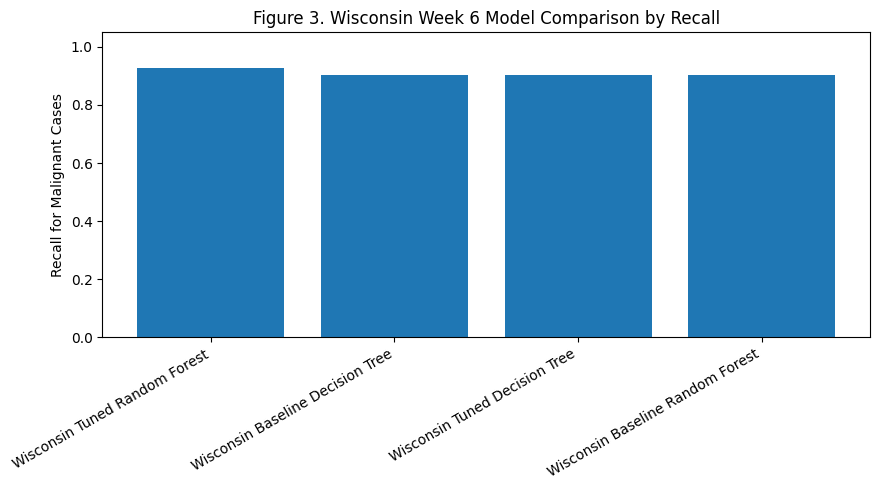

In [13]:
# Figure 3: Wisconsin Week 6 model comparison by recall
plot_df = wisconsin_week6_results_df.sort_values("test_recall_positive", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["test_recall_positive"])
plt.ylabel("Recall for Malignant Cases")
plt.title("Figure 3. Wisconsin Week 6 Model Comparison by Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


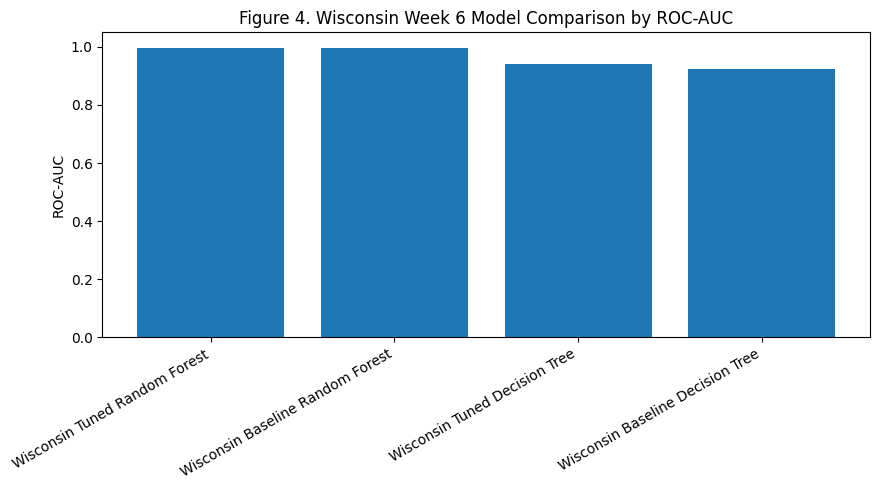

In [14]:
# Figure 4: Wisconsin Week 6 model comparison by ROC-AUC
plot_df = wisconsin_week6_results_df.sort_values("test_roc_auc", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["test_roc_auc"])
plt.ylabel("ROC-AUC")
plt.title("Figure 4. Wisconsin Week 6 Model Comparison by ROC-AUC")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 13. Wisconsin confusion matrix and ROC curve for best model

I select the best Wisconsin Week 6 model based on recall and ROC-AUC.


Best Wisconsin Week 6 model: Wisconsin Tuned Random Forest

Classification report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



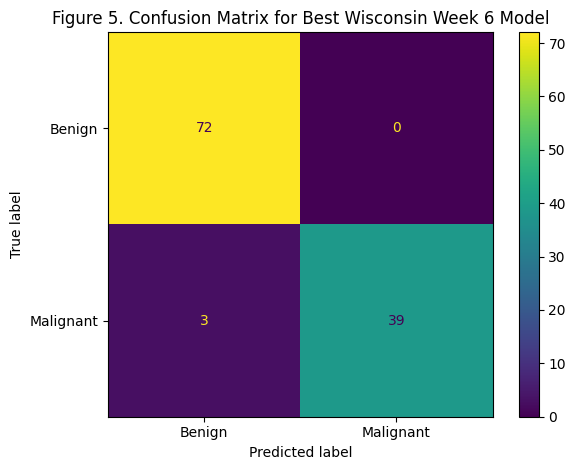

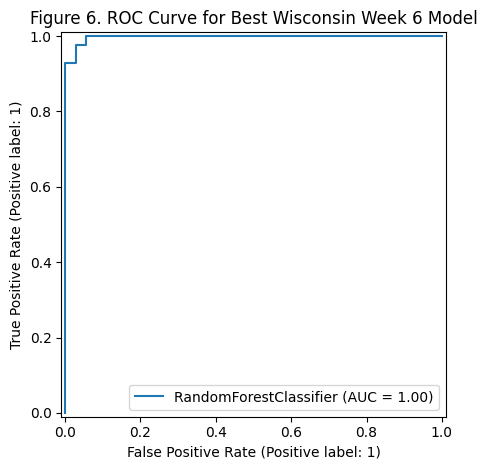

In [15]:
best_w_model_row = wisconsin_week6_results_df.sort_values(
    ["test_recall_positive", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

best_w_model_name = best_w_model_row["model"]

wisconsin_model_lookup = {
    "Wisconsin Baseline Decision Tree": wisconsin_tree_baseline,
    "Wisconsin Tuned Decision Tree": wisconsin_tree_grid.best_estimator_,
    "Wisconsin Baseline Random Forest": wisconsin_rf_baseline,
    "Wisconsin Tuned Random Forest": wisconsin_rf_grid.best_estimator_
}

best_w_model = wisconsin_model_lookup[best_w_model_name]
best_w_model.fit(X_train_w, y_train_w)
best_w_pred = best_w_model.predict(X_test_w)

print("Best Wisconsin Week 6 model:", best_w_model_name)
print("\nClassification report:")
print(classification_report(y_test_w, best_w_pred, target_names=["Benign", "Malignant"]))

cm_w = confusion_matrix(y_test_w, best_w_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_w,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Figure 5. Confusion Matrix for Best Wisconsin Week 6 Model")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(best_w_model, X_test_w, y_test_w)
plt.title("Figure 6. ROC Curve for Best Wisconsin Week 6 Model")
plt.tight_layout()
plt.show()


## 14. Wisconsin feature importance

Tree-based models are helpful because they can show feature importance. This helps me understand which tumor measurements were most useful to the model.


In [16]:
# Use tuned random forest for feature importance because it is usually more stable than one tree.
w_feature_importance = pd.DataFrame({
    "feature": wisconsin_features,
    "importance": wisconsin_rf_grid.best_estimator_.feature_importances_
}).sort_values("importance", ascending=False)

w_feature_importance.head(15)


,feature,importance
23,worst_area,0.161682
27,worst_concave_points,0.125314
7,mean_concave_points,0.090555
22,worst_perimeter,0.090346
20,worst_radius,0.082581
2,mean_perimeter,0.080784
6,mean_concavity,0.059422
0,mean_radius,0.046483
3,mean_area,0.040475
26,worst_concavity,0.034204


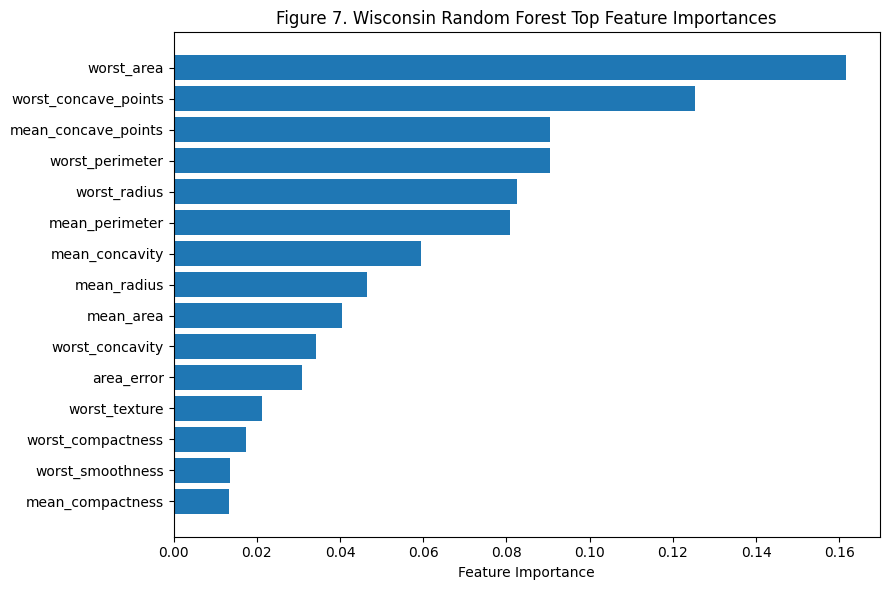

In [17]:
# Figure 7: Wisconsin random forest feature importance
plot_df = w_feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Feature Importance")
plt.title("Figure 7. Wisconsin Random Forest Top Feature Importances")
plt.tight_layout()
plt.show()


### Wisconsin Week 6 interpretation

For the Wisconsin dataset, I expected the random forest to perform well because the dataset has many numeric tumor features and possible interactions. A single decision tree is easier to interpret, but it can overfit. The random forest helps reduce that overfitting by combining many trees.

If the important features are mostly radius, perimeter, area, concavity, or worst-case tumor measurements, that supports my earlier findings that tumor size and shape are major signals for diagnosis.


# Part B: Breast Cancer Coimbra Dataset

## 15. Load and prepare the Coimbra dataset

The Coimbra dataset target is called `Classification`.

The original coding is:

- `1 = Healthy controls`
- `2 = Patients with breast cancer`

I create:

- `breast_cancer_present = 1` for breast cancer patients
- `breast_cancer_present = 0` for healthy controls


In [18]:
coimbra_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"

coimbra_df = pd.read_csv(coimbra_url)

coimbra_df.columns = (
    coimbra_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace(".", "_", regex=False)
)

coimbra_df["breast_cancer_present"] = (coimbra_df["Classification"] == 2).astype(int)
coimbra_df["diagnosis_group"] = np.where(coimbra_df["breast_cancer_present"] == 1, "Patient", "Healthy Control")

print("Coimbra dataset shape:", coimbra_df.shape)
print("\nClass counts:")
print(coimbra_df["diagnosis_group"].value_counts())

print("\nClass percentages:")
print(coimbra_df["diagnosis_group"].value_counts(normalize=True).round(3))

print("\nMissing values:")
print(coimbra_df.isna().sum())

coimbra_df.head()


Coimbra dataset shape: (116, 12)

Class counts:
diagnosis_group
Patient            64
Healthy Control    52
Name: count, dtype: int64

Class percentages:
diagnosis_group
Patient            0.552
Healthy Control    0.448
Name: proportion, dtype: float64

Missing values:
Age                      0
BMI                      0
Glucose                  0
Insulin                  0
HOMA                     0
Leptin                   0
Adiponectin              0
Resistin                 0
MCP_1                    0
Classification           0
breast_cancer_present    0
diagnosis_group          0
dtype: int64


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP_1,Classification,breast_cancer_present,diagnosis_group
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1,0,Healthy Control
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1,0,Healthy Control
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1,0,Healthy Control
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1,0,Healthy Control
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1,0,Healthy Control


## 16. Coimbra features and target

The Coimbra dataset has 9 predictors. These are clinical and blood-based markers rather than tumor image measurements.


In [19]:
coimbra_target = "breast_cancer_present"
coimbra_label = "diagnosis_group"

coimbra_features = [
    col for col in coimbra_df.columns
    if col not in ["Classification", coimbra_target, coimbra_label]
]

X_c = coimbra_df[coimbra_features]
y_c = coimbra_df[coimbra_target]

print("Coimbra features:")
print(coimbra_features)

print("\nNumber of rows:", X_c.shape[0])
print("Number of features:", X_c.shape[1])


Coimbra features:
['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP_1']

Number of rows: 116
Number of features: 9


## 17. Quick Coimbra EDA before tree models

Before using trees, I check how predictors differ between breast cancer patients and healthy controls.


In [20]:
coimbra_group_means = coimbra_df.groupby("diagnosis_group")[coimbra_features].mean().T
coimbra_group_means["difference_patient_minus_control"] = (
    coimbra_group_means["Patient"] - coimbra_group_means["Healthy Control"]
)

coimbra_group_means.sort_values("difference_patient_minus_control")


diagnosis_group,Healthy Control,Patient,difference_patient_minus_control
Age,58.076923,56.671875,-1.405048
BMI,28.317336,26.984740,-1.332596
Adiponectin,10.328205,10.061167,-0.267038
Leptin,26.637933,26.596512,-0.041420
HOMA,1.552398,3.623342,2.070944
Insulin,6.933769,12.513219,5.579450
Resistin,11.614813,17.253777,5.638964
Glucose,88.230769,105.562500,17.331731
MCP_1,499.730692,563.016500,63.285808


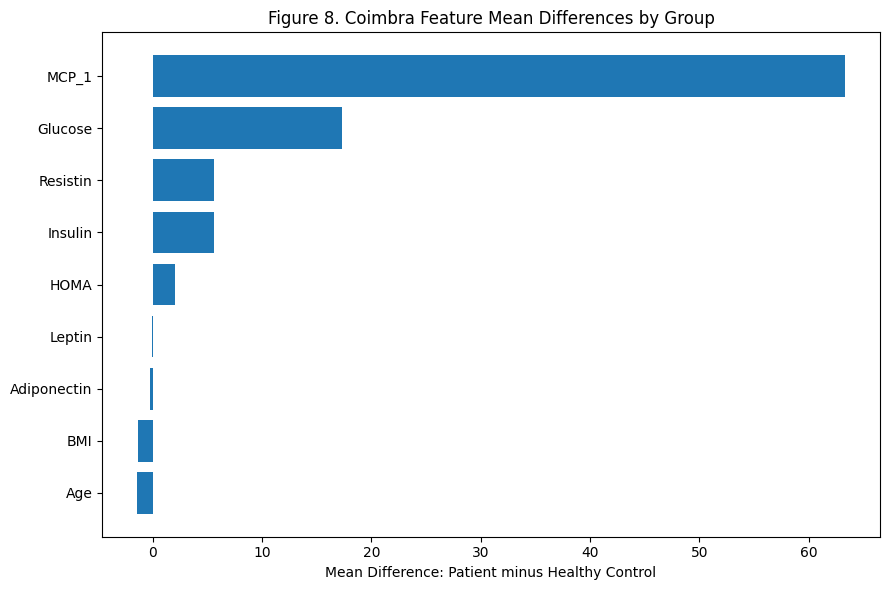

In [21]:
# Figure 8: Coimbra feature mean differences
plot_df = coimbra_group_means.sort_values("difference_patient_minus_control")

plt.figure(figsize=(9, 6))
plt.barh(plot_df.index, plot_df["difference_patient_minus_control"])
plt.xlabel("Mean Difference: Patient minus Healthy Control")
plt.title("Figure 8. Coimbra Feature Mean Differences by Group")
plt.tight_layout()
plt.show()


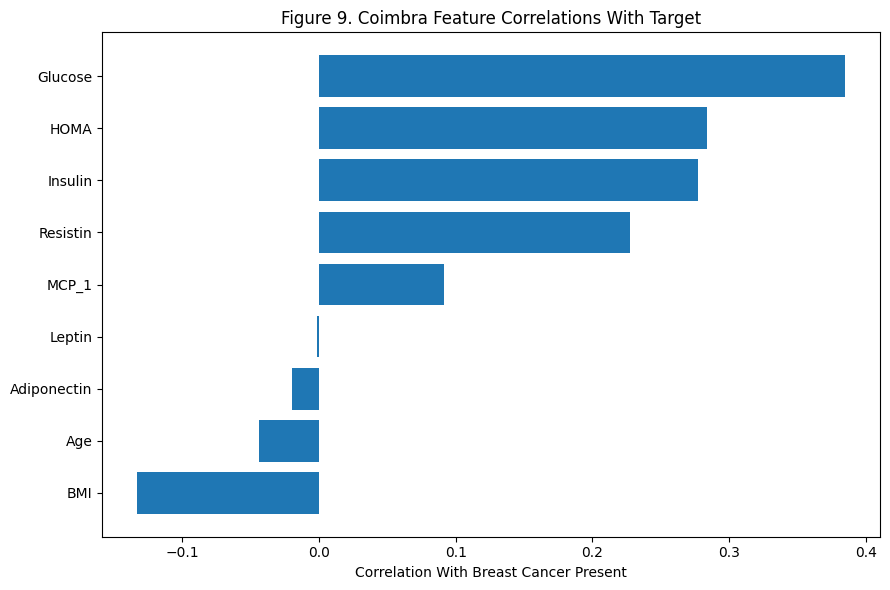

,feature,correlation_with_breast_cancer_present
0,BMI,-0.132586
1,Age,-0.043555
2,Adiponectin,-0.019490
3,Leptin,-0.001078
4,MCP_1,0.091381
5,Resistin,0.227310
6,Insulin,0.276804
7,HOMA,0.284012
8,Glucose,0.384315


In [22]:
# Figure 9: Coimbra correlations with breast cancer status
coimbra_corr_with_target = coimbra_df[coimbra_features + [coimbra_target]].corr()[coimbra_target].drop(coimbra_target)
coimbra_corr_sorted = coimbra_corr_with_target.sort_values()

plt.figure(figsize=(9, 6))
plt.barh(coimbra_corr_sorted.index, coimbra_corr_sorted.values)
plt.xlabel("Correlation With Breast Cancer Present")
plt.title("Figure 9. Coimbra Feature Correlations With Target")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": coimbra_corr_sorted.index,
    "correlation_with_breast_cancer_present": coimbra_corr_sorted.values
})


### Coimbra EDA note

The Coimbra dataset is smaller and uses indirect clinical biomarkers. Because of that, I expect it to be harder to model than Wisconsin. Tree models may still help because they can capture nonlinear splits, such as whether a biomarker is above or below a certain value.


## 18. Coimbra train-test split

I use a stratified split because I want the training and testing sets to have similar proportions of patients and healthy controls.


In [23]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c,
    y_c,
    test_size=0.20,
    random_state=42,
    stratify=y_c
)

print("Training shape:", X_train_c.shape)
print("Testing shape:", X_test_c.shape)

print("\nTraining target distribution:")
print(y_train_c.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test_c.value_counts(normalize=True).round(3))


Training shape: (92, 9)
Testing shape: (24, 9)

Training target distribution:
breast_cancer_present
1    0.554
0    0.446
Name: proportion, dtype: float64

Testing target distribution:
breast_cancer_present
1    0.542
0    0.458
Name: proportion, dtype: float64


## 19. Coimbra baseline decision tree

I start with a basic decision tree. Since Coimbra is small, I expect an unrestricted tree may overfit.


In [24]:
coimbra_tree_baseline = DecisionTreeClassifier(
    random_state=42
)

c_tree_base_results, c_tree_base_train_pred, c_tree_base_test_pred, c_tree_base_train_score, c_tree_base_test_score = evaluate_classifier(
    "Coimbra Baseline Decision Tree",
    coimbra_tree_baseline,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([c_tree_base_results])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Coimbra Baseline Decision Tree,1.0,0.625,0.7,0.538462,0.608696,0.632867


## 20. Coimbra tuned decision tree

I tune the decision tree to reduce overfitting. This is especially important because the Coimbra dataset only has 116 rows.


In [25]:
coimbra_tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=tree_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1
)

coimbra_tree_grid.fit(X_train_c, y_train_c)

print("Best Coimbra decision tree parameters:")
print(coimbra_tree_grid.best_params_)
print("\nBest cross-validated recall:", coimbra_tree_grid.best_score_)

c_tree_tuned_results, c_tree_tuned_train_pred, c_tree_tuned_test_pred, c_tree_tuned_train_score, c_tree_tuned_test_score = evaluate_classifier(
    "Coimbra Tuned Decision Tree",
    coimbra_tree_grid.best_estimator_,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([c_tree_base_results, c_tree_tuned_results])


Best Coimbra decision tree parameters:
{'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 8, 'min_samples_split': 2}

Best cross-validated recall: 0.7418181818181818


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Coimbra Baseline Decision Tree,1.000000,0.625,0.700000,0.538462,0.608696,0.632867
1,Coimbra Tuned Decision Tree,0.782609,0.625,0.666667,0.615385,0.640000,0.597902


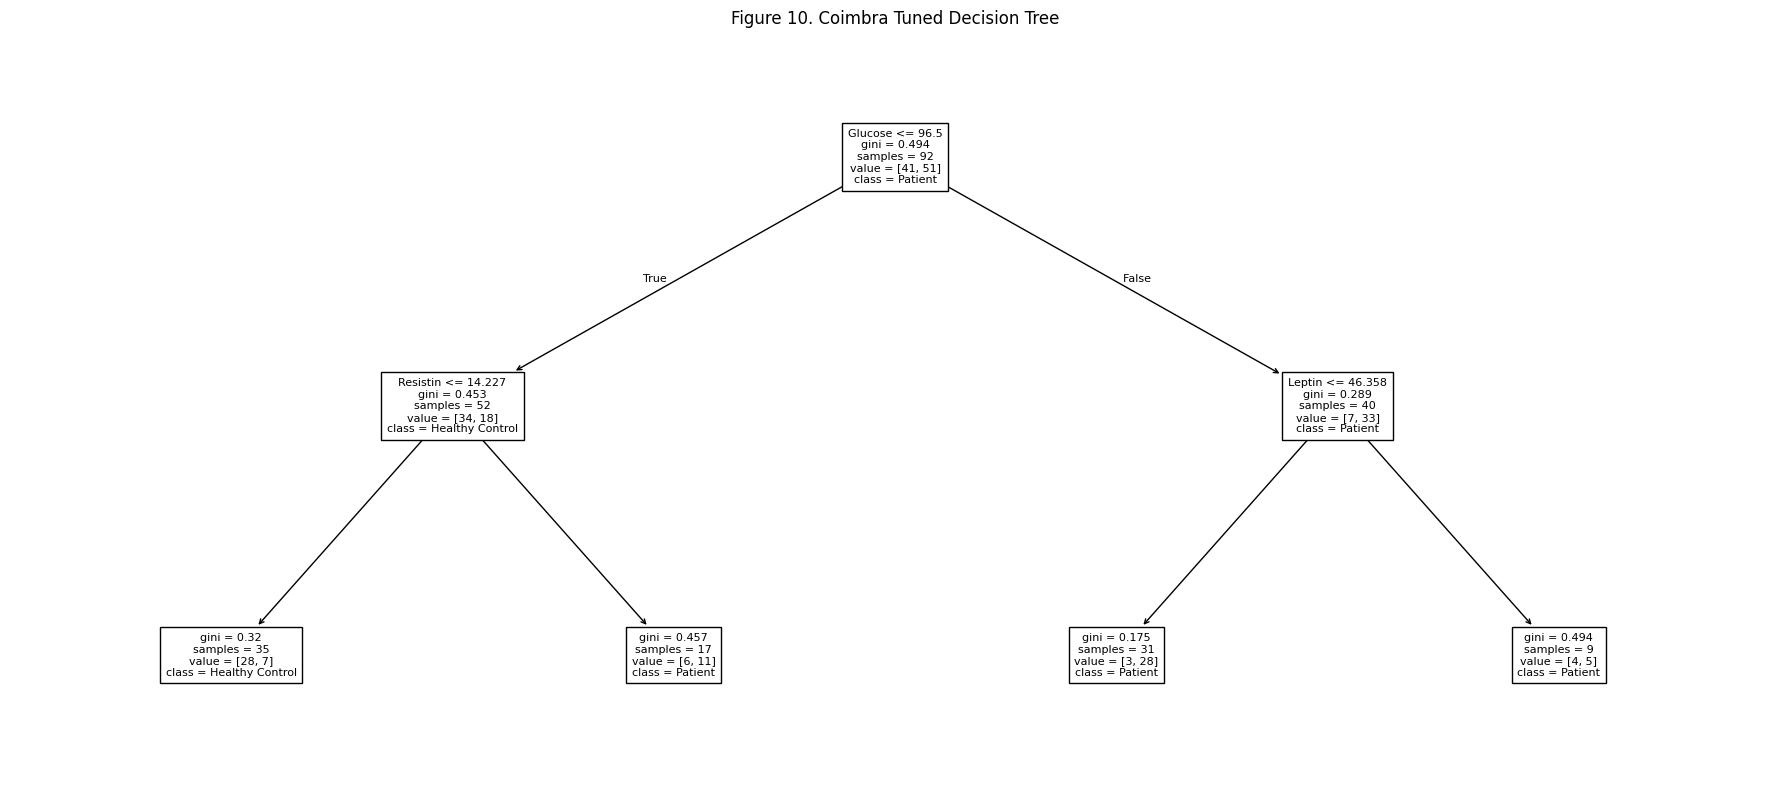

In [26]:
# Figure 10: Coimbra tuned decision tree visualization
plt.figure(figsize=(18, 8))
plot_tree(
    coimbra_tree_grid.best_estimator_,
    feature_names=coimbra_features,
    class_names=["Healthy Control", "Patient"],
    max_depth=3,
    fontsize=8
)
plt.title("Figure 10. Coimbra Tuned Decision Tree")
plt.tight_layout()
plt.show()


## 21. Coimbra random forest

A random forest may improve stability by combining many trees. Since Coimbra is small, I still need to be careful about overfitting.


In [27]:
coimbra_rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

c_rf_base_results, c_rf_base_train_pred, c_rf_base_test_pred, c_rf_base_train_score, c_rf_base_test_score = evaluate_classifier(
    "Coimbra Baseline Random Forest",
    coimbra_rf_baseline,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([c_tree_tuned_results, c_rf_base_results])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Coimbra Tuned Decision Tree,0.782609,0.625000,0.666667,0.615385,0.640000,0.597902
1,Coimbra Baseline Random Forest,1.000000,0.708333,0.800000,0.615385,0.695652,0.832168


## 22. Coimbra tuned random forest

I tune the random forest using the same general hyperparameters as Wisconsin:

- `n_estimators`
- `max_depth`
- `min_samples_leaf`
- `max_features`

The goal is to improve generalization and reduce overfitting.


In [28]:
coimbra_rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=rf_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1
)

coimbra_rf_grid.fit(X_train_c, y_train_c)

print("Best Coimbra random forest parameters:")
print(coimbra_rf_grid.best_params_)
print("\nBest cross-validated recall:", coimbra_rf_grid.best_score_)

c_rf_tuned_results, c_rf_tuned_train_pred, c_rf_tuned_test_pred, c_rf_tuned_train_score, c_rf_tuned_test_score = evaluate_classifier(
    "Coimbra Tuned Random Forest",
    coimbra_rf_grid.best_estimator_,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([c_tree_tuned_results, c_rf_base_results, c_rf_tuned_results])


Best Coimbra random forest parameters:
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}

Best cross-validated recall: 0.76


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Coimbra Tuned Decision Tree,0.782609,0.625000,0.666667,0.615385,0.640000,0.597902
1,Coimbra Baseline Random Forest,1.000000,0.708333,0.800000,0.615385,0.695652,0.832168
2,Coimbra Tuned Random Forest,0.989130,0.666667,0.777778,0.538462,0.636364,0.839161


## 23. Coimbra model comparison

Now I compare the Coimbra decision tree and random forest models.


In [29]:
coimbra_week6_results_df = pd.DataFrame([
    c_tree_base_results,
    c_tree_tuned_results,
    c_rf_base_results,
    c_rf_tuned_results
])

coimbra_week6_results_df.sort_values(["test_recall_positive", "test_roc_auc"], ascending=[False, False])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
2,Coimbra Baseline Random Forest,1.000000,0.708333,0.800000,0.615385,0.695652,0.832168
1,Coimbra Tuned Decision Tree,0.782609,0.625000,0.666667,0.615385,0.640000,0.597902
3,Coimbra Tuned Random Forest,0.989130,0.666667,0.777778,0.538462,0.636364,0.839161
0,Coimbra Baseline Decision Tree,1.000000,0.625000,0.700000,0.538462,0.608696,0.632867


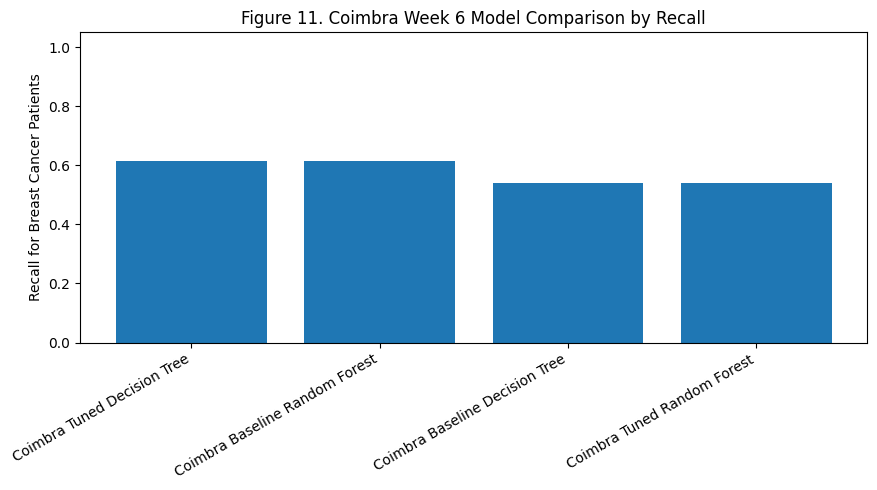

In [30]:
# Figure 11: Coimbra model comparison by recall
plot_df = coimbra_week6_results_df.sort_values("test_recall_positive", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["test_recall_positive"])
plt.ylabel("Recall for Breast Cancer Patients")
plt.title("Figure 11. Coimbra Week 6 Model Comparison by Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


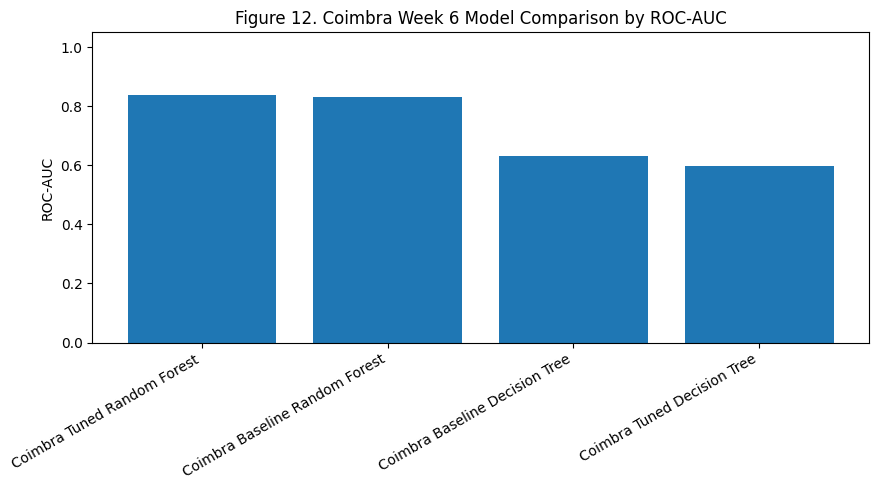

In [31]:
# Figure 12: Coimbra model comparison by ROC-AUC
plot_df = coimbra_week6_results_df.sort_values("test_roc_auc", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["test_roc_auc"])
plt.ylabel("ROC-AUC")
plt.title("Figure 12. Coimbra Week 6 Model Comparison by ROC-AUC")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 24. Coimbra confusion matrix and ROC curve for best model

I select the best Coimbra Week 6 model based on recall and ROC-AUC.


Best Coimbra Week 6 model: Coimbra Baseline Random Forest

Classification report:
                 precision    recall  f1-score   support

Healthy Control       0.64      0.82      0.72        11
        Patient       0.80      0.62      0.70        13

       accuracy                           0.71        24
      macro avg       0.72      0.72      0.71        24
   weighted avg       0.73      0.71      0.71        24



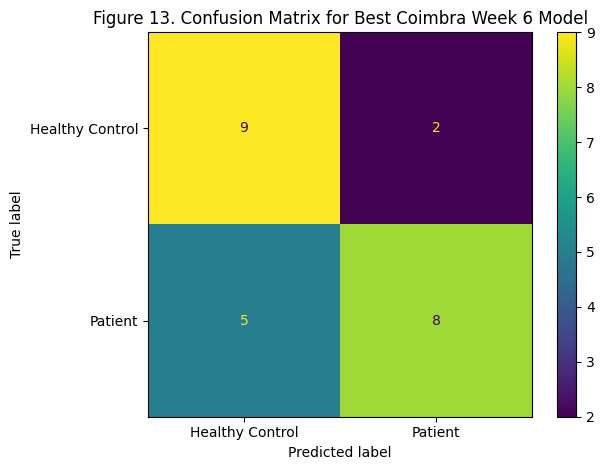

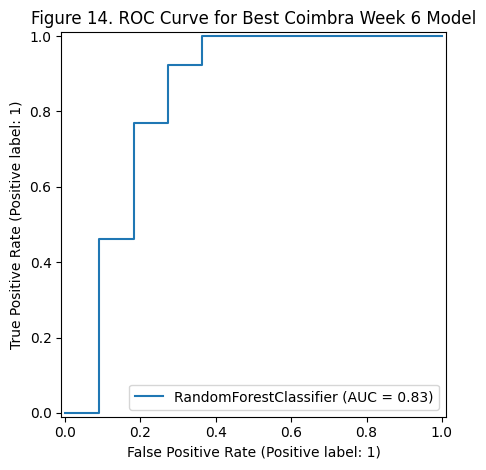

In [32]:
best_c_model_row = coimbra_week6_results_df.sort_values(
    ["test_recall_positive", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

best_c_model_name = best_c_model_row["model"]

coimbra_model_lookup = {
    "Coimbra Baseline Decision Tree": coimbra_tree_baseline,
    "Coimbra Tuned Decision Tree": coimbra_tree_grid.best_estimator_,
    "Coimbra Baseline Random Forest": coimbra_rf_baseline,
    "Coimbra Tuned Random Forest": coimbra_rf_grid.best_estimator_
}

best_c_model = coimbra_model_lookup[best_c_model_name]
best_c_model.fit(X_train_c, y_train_c)
best_c_pred = best_c_model.predict(X_test_c)

print("Best Coimbra Week 6 model:", best_c_model_name)
print("\nClassification report:")
print(classification_report(y_test_c, best_c_pred, target_names=["Healthy Control", "Patient"]))

cm_c = confusion_matrix(y_test_c, best_c_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_c,
    display_labels=["Healthy Control", "Patient"]
)

disp.plot()
plt.title("Figure 13. Confusion Matrix for Best Coimbra Week 6 Model")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(best_c_model, X_test_c, y_test_c)
plt.title("Figure 14. ROC Curve for Best Coimbra Week 6 Model")
plt.tight_layout()
plt.show()


## 25. Coimbra feature importance

I use the tuned random forest to look at feature importance because it is usually more stable than one single tree.


In [33]:
c_feature_importance = pd.DataFrame({
    "feature": coimbra_features,
    "importance": coimbra_rf_grid.best_estimator_.feature_importances_
}).sort_values("importance", ascending=False)

c_feature_importance


,feature,importance
2,Glucose,0.260571
7,Resistin,0.149742
0,Age,0.111622
1,BMI,0.098869
3,Insulin,0.097322
5,Leptin,0.095529
4,HOMA,0.085352
8,MCP_1,0.052061
6,Adiponectin,0.048933


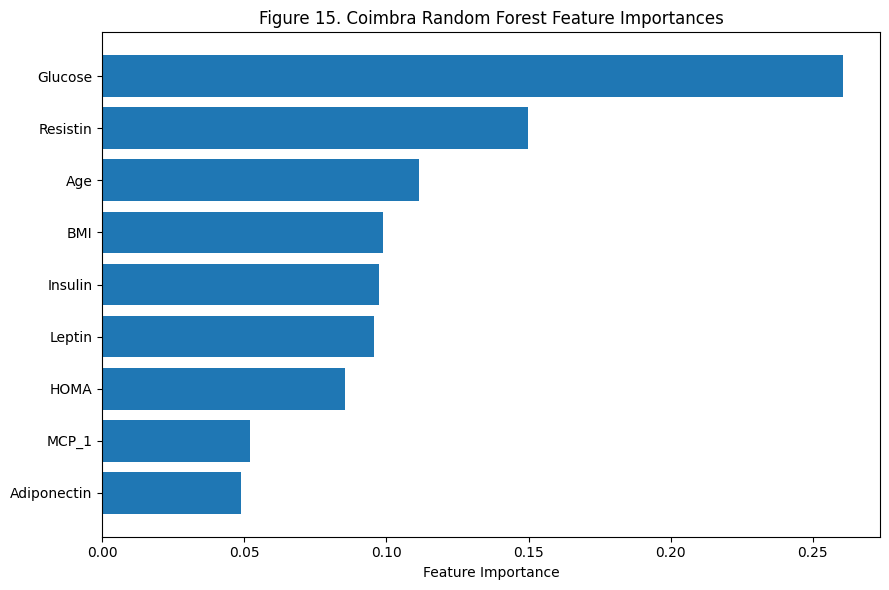

In [34]:
# Figure 15: Coimbra feature importance
plot_df = c_feature_importance.sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Feature Importance")
plt.title("Figure 15. Coimbra Random Forest Feature Importances")
plt.tight_layout()
plt.show()


### Coimbra Week 6 interpretation

For Coimbra, I expected performance to be less stable than Wisconsin because the dataset is much smaller and the predictors are more indirect. A decision tree may be easy to explain, but it can overfit quickly. A random forest should be more stable because it averages many trees.

Feature importance helps show which clinical or blood-based markers were most useful for prediction. This is important because it connects the model back to the healthcare context.


# Part C: Week 6 Comparison Across Both Datasets

## 26. Wisconsin vs. Coimbra Week 6 comparison

Now I compare the Week 6 results across both datasets. This helps me answer a larger capstone question: do image-based tumor measurements or clinical blood-based biomarkers provide stronger predictive information?


In [35]:
wisconsin_summary_for_comparison = wisconsin_week6_results_df.copy()
wisconsin_summary_for_comparison["dataset"] = "Wisconsin"

coimbra_summary_for_comparison = coimbra_week6_results_df.copy()
coimbra_summary_for_comparison["dataset"] = "Coimbra"

week6_combined_results = pd.concat(
    [wisconsin_summary_for_comparison, coimbra_summary_for_comparison],
    ignore_index=True
)

week6_combined_results.sort_values(["test_recall_positive", "test_roc_auc"], ascending=[False, False])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc,dataset
3,Wisconsin Tuned Random Forest,0.993407,0.973684,1.000000,0.928571,0.962963,0.997354,Wisconsin
2,Wisconsin Baseline Random Forest,1.000000,0.964912,1.000000,0.904762,0.950000,0.996032,Wisconsin
1,Wisconsin Tuned Decision Tree,0.991209,0.938596,0.926829,0.904762,0.915663,0.942460,Wisconsin
0,Wisconsin Baseline Decision Tree,1.000000,0.929825,0.904762,0.904762,0.904762,0.924603,Wisconsin
6,Coimbra Baseline Random Forest,1.000000,0.708333,0.800000,0.615385,0.695652,0.832168,Coimbra
5,Coimbra Tuned Decision Tree,0.782609,0.625000,0.666667,0.615385,0.640000,0.597902,Coimbra
7,Coimbra Tuned Random Forest,0.989130,0.666667,0.777778,0.538462,0.636364,0.839161,Coimbra
4,Coimbra Baseline Decision Tree,1.000000,0.625000,0.700000,0.538462,0.608696,0.632867,Coimbra


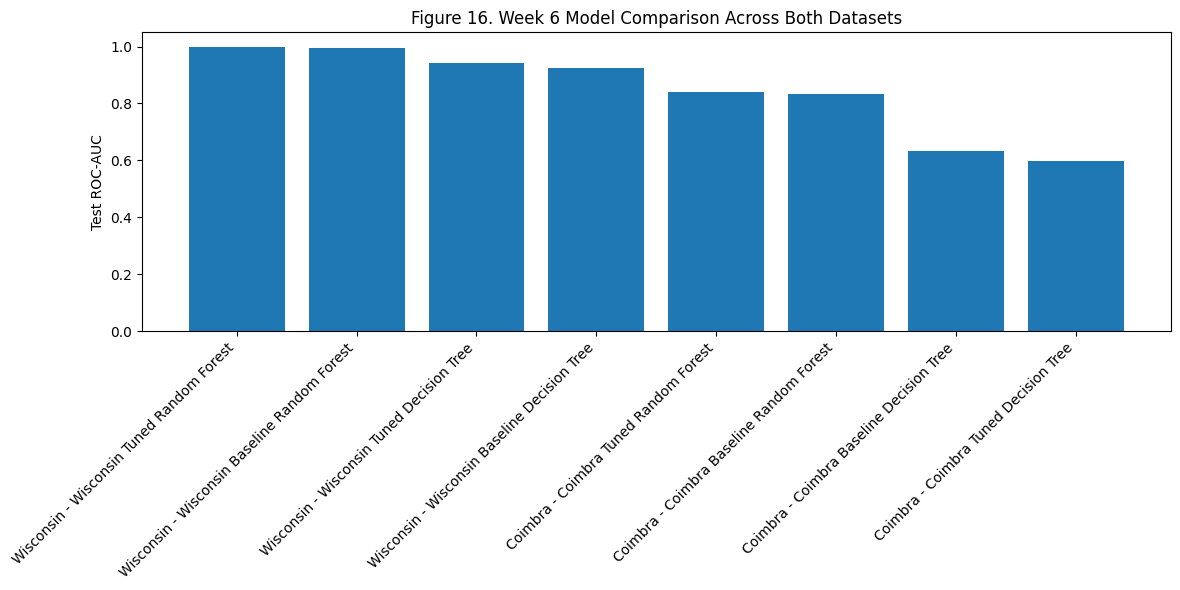

In [36]:
# Figure 16: Combined Week 6 comparison by ROC-AUC
plot_df = week6_combined_results.sort_values("test_roc_auc", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["dataset"] + " - " + plot_df["model"], plot_df["test_roc_auc"])
plt.ylabel("Test ROC-AUC")
plt.title("Figure 16. Week 6 Model Comparison Across Both Datasets")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 27.Week 6 summary

This cell prints a short summary using the actual notebook results. I can use this when writing the Week 7 Milestone One summary.


In [37]:
best_w_row = wisconsin_week6_results_df.sort_values(
    ["test_recall_positive", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

best_c_row = coimbra_week6_results_df.sort_values(
    ["test_recall_positive", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

print("Week 6 Summary")

print("Best Wisconsin Week 6 model:")
print(best_w_row["model"])
print(f"Test accuracy: {best_w_row['test_accuracy']:.4f}")
print(f"Test recall for malignant cases: {best_w_row['test_recall_positive']:.4f}")
print(f"Test precision for malignant cases: {best_w_row['test_precision_positive']:.4f}")
print(f"Test F1: {best_w_row['test_f1_positive']:.4f}")
print(f"Test ROC-AUC: {best_w_row['test_roc_auc']:.4f}")

print("\nBest Coimbra Week 6 model:")
print(best_c_row["model"])
print(f"Test accuracy: {best_c_row['test_accuracy']:.4f}")
print(f"Test recall for patients: {best_c_row['test_recall_positive']:.4f}")
print(f"Test precision for patients: {best_c_row['test_precision_positive']:.4f}")
print(f"Test F1: {best_c_row['test_f1_positive']:.4f}")
print(f"Test ROC-AUC: {best_c_row['test_roc_auc']:.4f}")

print("\nBest Wisconsin decision tree parameters:")
print(wisconsin_tree_grid.best_params_)

print("\nBest Wisconsin random forest parameters:")
print(wisconsin_rf_grid.best_params_)

print("\nBest Coimbra decision tree parameters:")
print(coimbra_tree_grid.best_params_)

print("\nBest Coimbra random forest parameters:")
print(coimbra_rf_grid.best_params_)


Week 6 Summary
Best Wisconsin Week 6 model:
Wisconsin Tuned Random Forest
Test accuracy: 0.9737
Test recall for malignant cases: 0.9286
Test precision for malignant cases: 1.0000
Test F1: 0.9630
Test ROC-AUC: 0.9974

Best Coimbra Week 6 model:
Coimbra Baseline Random Forest
Test accuracy: 0.7083
Test recall for patients: 0.6154
Test precision for patients: 0.8000
Test F1: 0.6957
Test ROC-AUC: 0.8322

Best Wisconsin decision tree parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}

Best Wisconsin random forest parameters:
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}

Best Coimbra decision tree parameters:
{'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 8, 'min_samples_split': 2}

Best Coimbra random forest parameters:
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}


## 28. Week 6 findings and interpretation

After running this Week 6 notebook, I learned that decision trees and random forests are useful because they can capture nonlinear patterns and interactions without requiring me to manually create interaction terms.

For the **Wisconsin dataset**, I expected tree-based models to perform well because the dataset has strong tumor morphology features. These features are directly related to the tumor, so they should provide strong information for predicting malignant versus benign diagnosis. The random forest was especially useful because it reduced the overfitting risk of a single decision tree and provided feature importance scores.

For the **Coimbra dataset**, I expected the models to be less stable because the dataset is smaller and the predictors are indirect clinical and blood-based markers. A single decision tree can overfit this kind of small dataset, so tuning tree depth and minimum leaf size was important. Random forest helped improve stability by averaging across many trees.

The main overfitting prevention steps were train-test splits, stratification, cross-validation, tree pruning through `max_depth`, `min_samples_leaf`, and `min_samples_split`, and random forest averaging. For random forest, I also tuned `n_estimators`, `max_depth`, `min_samples_leaf`, and `max_features`.

Overall, Week 6 strengthened my capstone because it gave me interpretable and high-performing models. Decision trees were easier to explain, but random forests were usually more reliable. Feature importance was especially helpful because it showed which tumor measurements or biomarkers mattered most in each dataset.


## 29. Wisconsin vs. Coimbra interpretation

The biggest difference between the two datasets is the type of information they contain. Wisconsin uses direct tumor image-based measurements, while Coimbra uses clinical and blood-based biomarkers. Because of that, I expect Wisconsin to generally perform better.

However, Coimbra is still valuable because it answers a different question. It helps show whether routine clinical and blood markers can support breast cancer prediction. Even if Coimbra performs lower than Wisconsin, it still adds value because it represents a different type of healthcare data.

For my final Milestone One paper, this comparison helps me explain that not all healthcare datasets provide the same predictive signal. Tumor morphology features appear more directly connected to diagnosis, while clinical biomarkers may provide useful but less direct information.


## 30. References

UCI Machine Learning Repository. (n.d.). *Breast Cancer Wisconsin (Diagnostic) dataset*. https://doi.org/10.24432/C5DW2B

Patrício, M., Pereira, J., Crisóstomo, J., Matafome, P., Seiça, R., & Caramelo, F. (2018). *Breast Cancer Coimbra* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P59

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Scikit-learn developers. (n.d.). *Decision trees*. https://scikit-learn.org/stable/modules/tree.html

Scikit-learn developers. (n.d.). *Random forests and other randomized tree ensembles*. https://scikit-learn.org/stable/modules/ensemble.html#forests-of-randomized-trees
